In [0]:
import pandas as pd
file_path ="/Volumes/workspace/default/netflix/netflix_FutureEnginnering.csv"
df = pd.read_csv(file_path)
display(df.head(5))

show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Content_Length_Category,Title_Length_Category,Original_vs_Licensed,Audience_Age_Group
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",Medium,Long Title,Original,Teens
s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",Regular Series,Medium Title,Licensed,Adults
s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",Mini-Series,Short Title,Licensed,Adults
s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",Mini-Series,Long Title,Licensed,Adults
s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",Regular Series,Medium Title,Licensed,Adults


In [0]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Content_Length_Category', 'Title_Length_Category',
       'Original_vs_Licensed', 'Audience_Age_Group'],
      dtype='object')

In [0]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
df['rating_encoded'] = le.fit_transform(df['rating'])
df['content_len_encoded'] = le.fit_transform(df['Content_Length_Category'])
df['title_len_encoded'] = le.fit_transform(df['Title_Length_Category'])
df['license_encoded'] = le.fit_transform(df['Original_vs_Licensed'])
df['audience_encoded'] = le.fit_transform(df['Audience_Age_Group'])
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Content_Length_Category,Title_Length_Category,Original_vs_Licensed,Audience_Age_Group,type_encoded,rating_encoded,content_len_encoded,title_len_encoded,license_encoded,audience_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Medium,Long Title,Original,Teens,0,7,2,0,1,3
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Regular Series,Medium Title,Licensed,Adults,1,11,4,1,0,0
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Mini-Series,Short Title,Licensed,Adults,1,11,3,2,0,0
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Mini-Series,Long Title,Licensed,Adults,1,11,3,0,0,0
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Regular Series,Medium Title,Licensed,Adults,1,11,4,1,0,0


In [0]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans

# Prepare genre features
mlb = MultiLabelBinarizer()
genres = df['listed_in'].str.split(', ')
genre_features = mlb.fit_transform(genres)
genre_df = pd.DataFrame(genre_features, columns=mlb.classes_)

# Prepare duration feature
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximate: 1 season = 60 min
        except:
            return 0
    else:
        return 0

duration_feature = df.apply(extract_duration, axis=1).values.reshape(-1, 1)

# Prepare rating feature (label encoding)
rating_map = {k: v for v, k in enumerate(df['rating'].unique())}
rating_feature = df['rating'].map(rating_map).fillna(0).values.reshape(-1, 1)

# Combine features
import numpy as np
df_features = pd.concat([
    df[['release_year', 'rating_encoded', 'type_encoded',
        'content_len_encoded', 'title_len_encoded',
        'license_encoded', 'audience_encoded']],
    genre_df
], axis=1)


# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

display(df[['title', 'listed_in', 'duration', 'rating', 'cluster']].head(5))


title,listed_in,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90 min,PG-13,1
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Seasons,TV-MA,4
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,TV-MA,4
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,TV-MA,4
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Seasons,TV-MA,4


In [0]:
cluster_counts = df['cluster'].value_counts().sort_index()
display(cluster_counts)

cluster
0     173
1    6015
2      69
3     116
4    2434
Name: count, dtype: int64

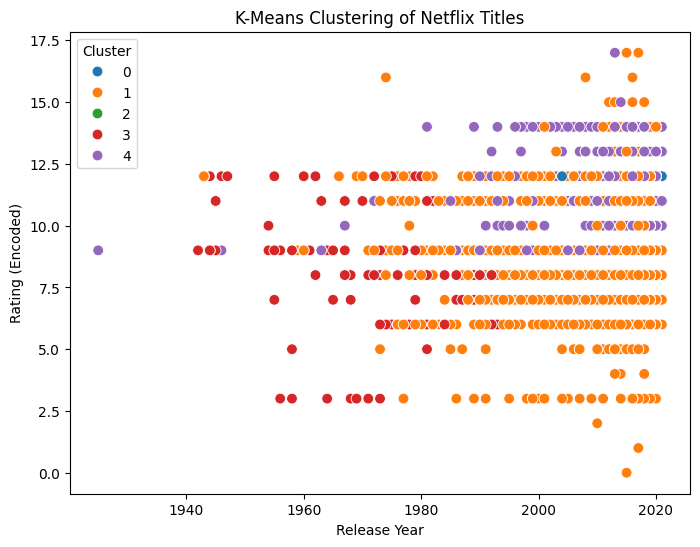

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['release_year'],
    y=df['rating_encoded'],
    hue=df['cluster'],
    palette='tab10',
    s=60
)
plt.title("K-Means Clustering of Netflix Titles")
plt.xlabel("Release Year")
plt.ylabel("Rating (Encoded)")
plt.legend(title="Cluster")
plt.show()


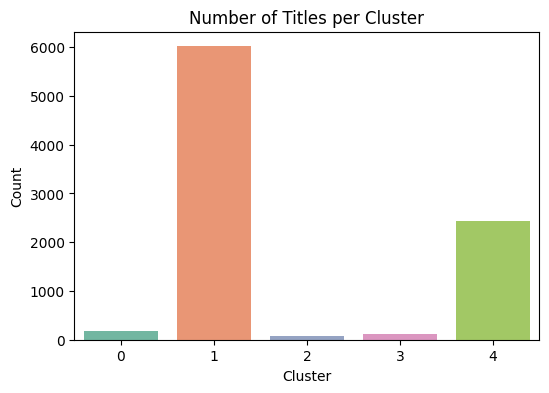

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='cluster', hue='cluster', data=df, palette='Set2', legend=False)
plt.title('Number of Titles per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()



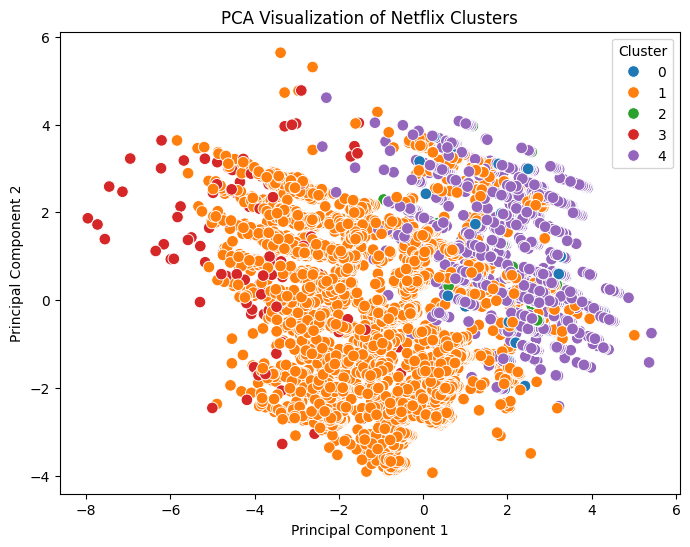

In [0]:
from sklearn.decomposition import PCA
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    palette='tab10',
    data=df,
    s=70
)
plt.title('PCA Visualization of Netflix Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [0]:
# Merge genre features with cluster labels
genre_df['cluster'] = df['cluster']

# Group by cluster and sum genre counts
cluster_genre_counts = genre_df.groupby('cluster').sum()

# Display top genres per cluster
cluster_genre_counts.head(5)


,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,Documentaries,Docuseries,Dramas,Faith & Spirituality,Horror Movies,Independent Movies,International Movies,International TV Shows,Kids' TV,Korean TV Shows,LGBTQ Movies,Movies,Music & Musicals,Reality TV,Romantic Movies,Romantic TV Shows,Sci-Fi & Fantasy,Science & Nature TV,Spanish-Language TV Shows,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,0,0,1,0,0,67,0,0,11,0,0,0,0,0,155,5,0,0,0,0,11,0,26,0,0,173,0,0,2,7,18,31,1,0,0,0,0,0,0
1,828,69,0,0,632,0,0,1651,0,58,857,0,2367,65,354,744,2732,0,0,0,101,57,370,0,612,0,242,0,0,216,343,0,0,0,0,0,0,0,0,0,0,574
2,0,0,15,0,0,0,0,0,1,0,0,1,0,0,0,0,0,26,4,0,0,0,0,4,0,10,0,0,1,0,0,0,1,16,32,3,1,2,0,0,69,0
3,31,2,0,0,9,0,116,23,0,13,12,0,60,0,3,12,20,0,0,0,1,0,5,0,4,0,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,3
4,0,0,160,253,0,27,0,0,402,0,0,383,0,0,0,0,0,1170,442,151,0,0,0,240,0,334,0,92,0,0,0,54,160,547,700,71,97,82,16,57,0,0


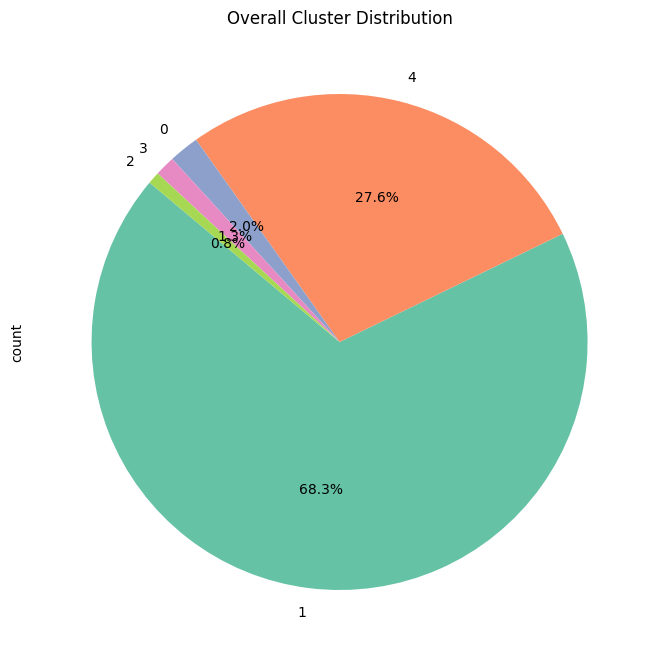

In [0]:
plt.figure(figsize=(8,15))
df['cluster'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2')
)
plt.title("Overall Cluster Distribution")
plt.show()


In [0]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
# Drop missing target values
df = df.dropna(subset=['type'])

# Encode categorical columns
label_encoders = {}
for col in [ 'rating', 'Original_vs_Licensed']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Extract numeric duration
def extract_duration(row):
    try:
        return int(str(row['duration']).split(' ')[0])
    except:
        return 0

df['duration_num'] = df.apply(extract_duration, axis=1)

# Define features and target
X = df[['release_year', 'rating', 'duration_num', 'Original_vs_Licensed']]
y = df['type']


In [0]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)


In [0]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Model Accuracy: 0.9988649262202043

Classification Report:
               precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1836
     Tv Show       1.00      1.00      1.00       807

    accuracy                           1.00      2643
   macro avg       1.00      1.00      1.00      2643
weighted avg       1.00      1.00      1.00      2643


Confusion Matrix:
 [[1835    1]
 [   2  805]]


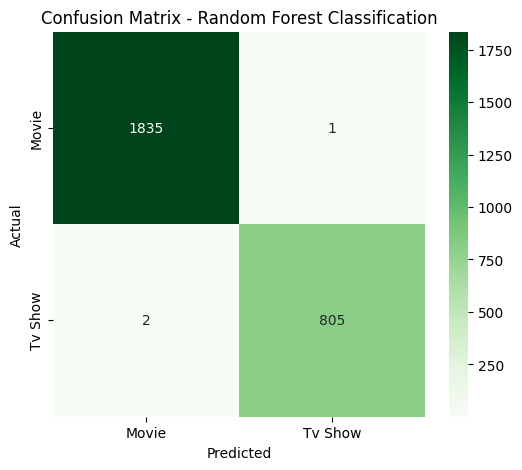

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)

plt.title("Confusion Matrix - Random Forest Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


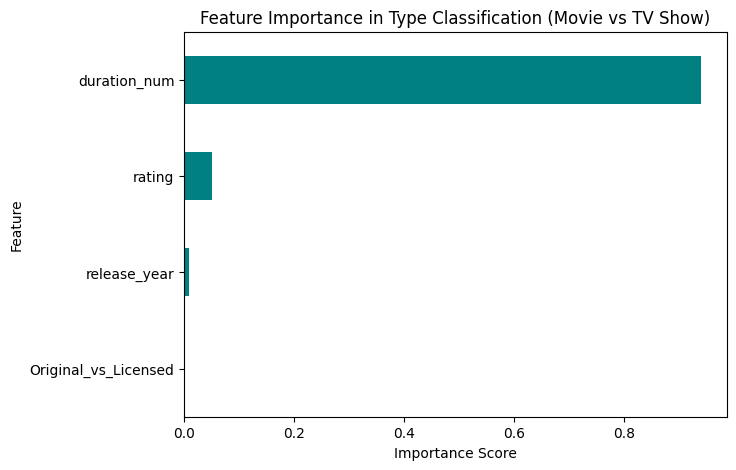

In [0]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(7,5), color='teal')
plt.title('Feature Importance in Type Classification (Movie vs TV Show)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()